Installing the Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

Data Collection

In [ ]:
# Loading the dataset to a pandas dataframe
wine_dataset = pd.read_csv("/content/winequality-red.csv")

In [ ]:
# Number of rows and columns in the dataset
wine_dataset.shape

(1599, 12)

In [ ]:
# Printing the first 5 rows of dataset
wine_dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# Checking for missing values
wine_dataset.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
# Statistical measures
wine_dataset.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Data Analysis and Visualization

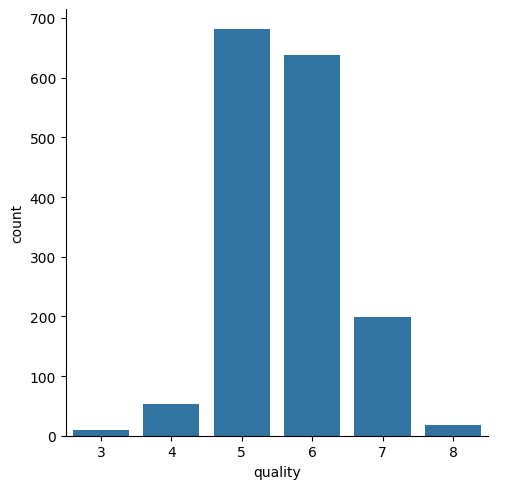

In [ ]:
# number of values for each quality
sns.catplot(x='quality', data=wine_dataset, kind='count')

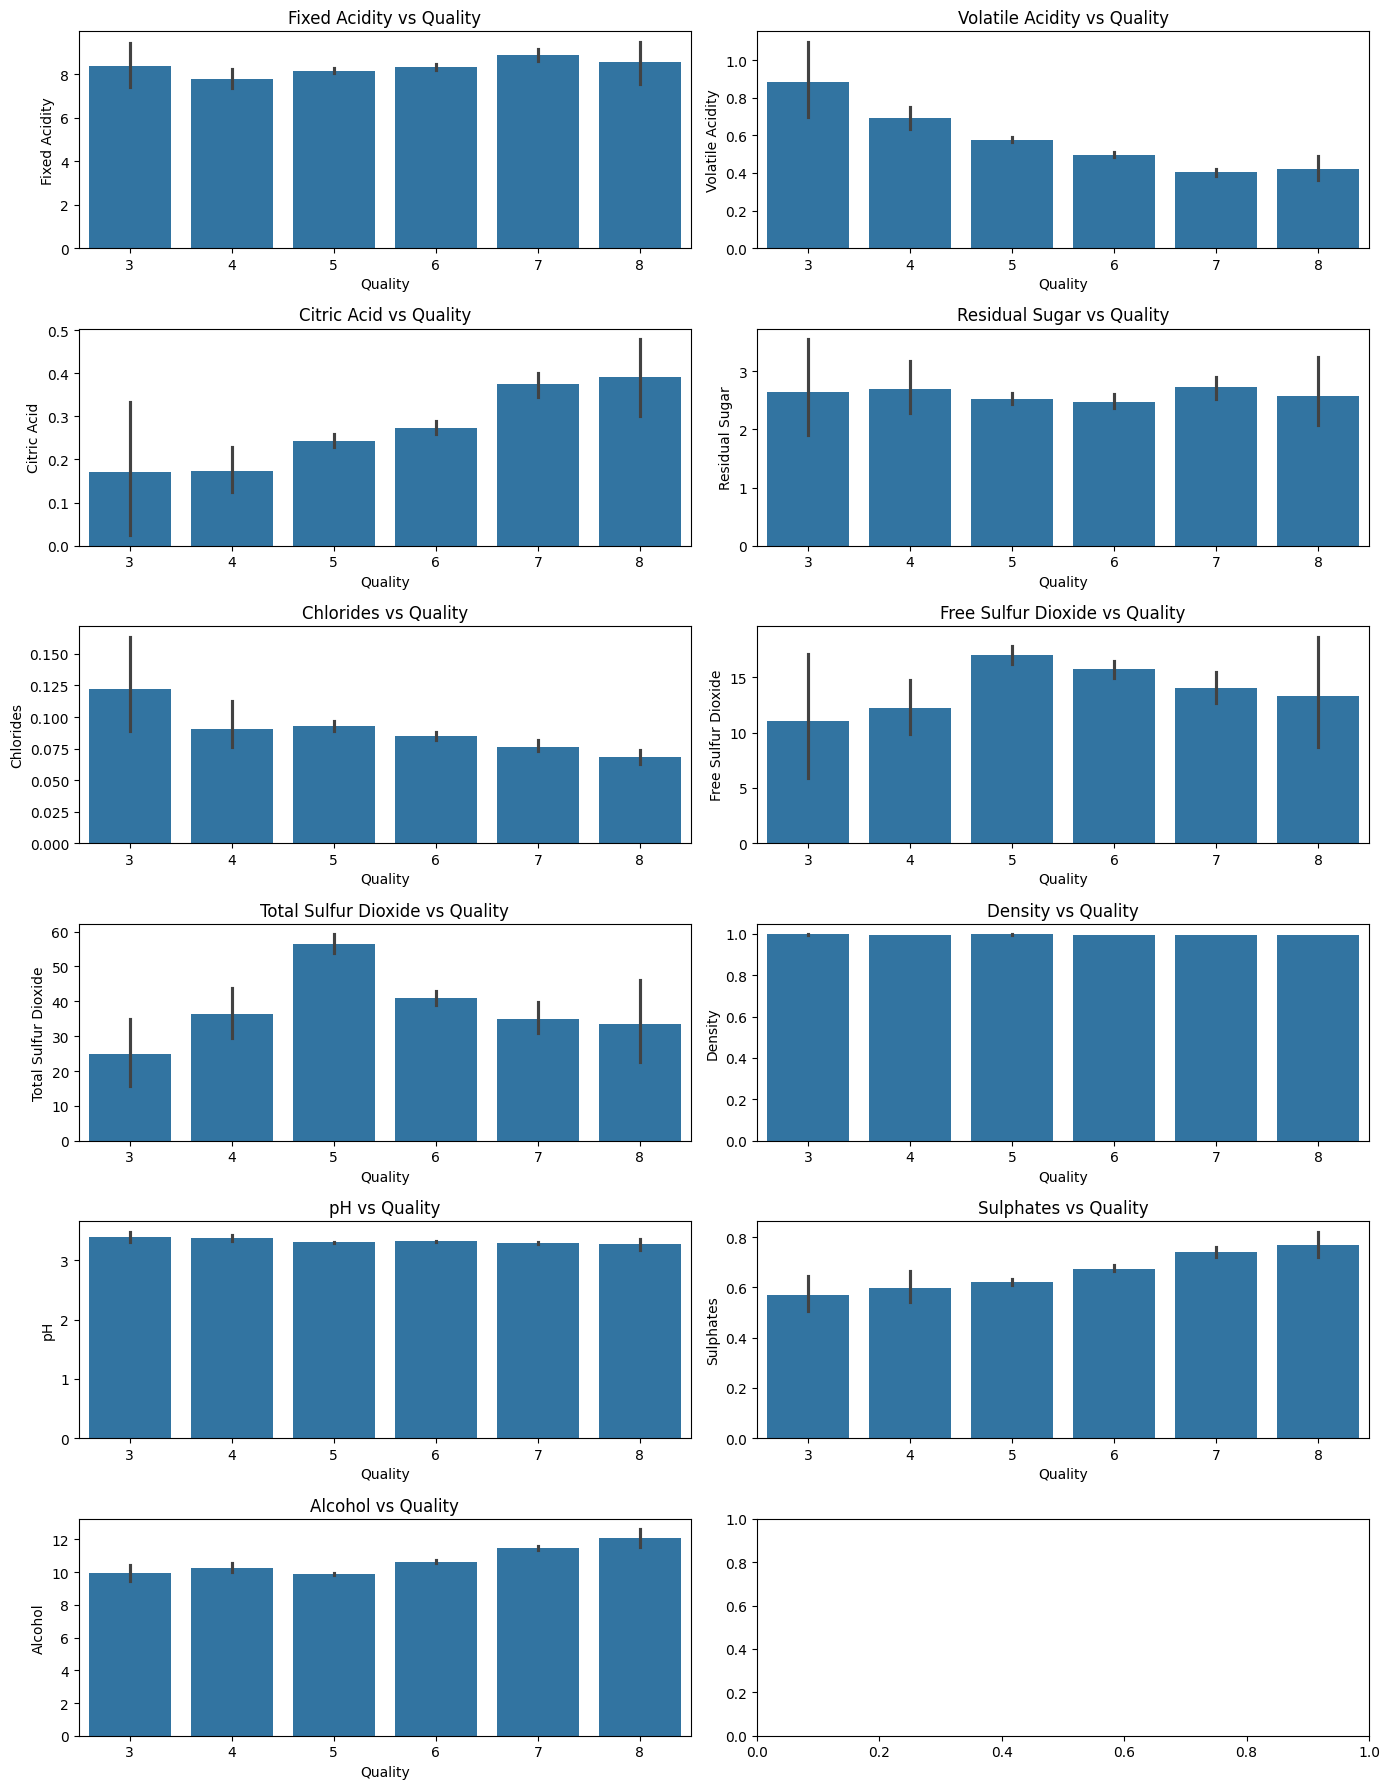

In [ ]:
# Create Subplots
fig, axes = plt.subplots(6, 2, figsize=(14, 18))  # 6 row, 2 columns

sns.barplot(x='quality', y='fixed acidity', data=wine_dataset, ax=axes[0, 0])
sns.barplot(x='quality', y='volatile acidity', data=wine_dataset, ax=axes[0, 1])
sns.barplot(x='quality', y='citric acid', data=wine_dataset, ax=axes[1, 0])
sns.barplot(x='quality', y='residual sugar', data=wine_dataset, ax=axes[1, 1])
sns.barplot(x='quality', y='chlorides', data=wine_dataset, ax=axes[2, 0])
sns.barplot(x='quality', y='free sulfur dioxide', data=wine_dataset, ax=axes[2, 1])
sns.barplot(x='quality', y='total sulfur dioxide', data=wine_dataset, ax=axes[3, 0])
sns.barplot(x='quality', y='density', data=wine_dataset, ax=axes[3, 1])
sns.barplot(x='quality', y='pH', data=wine_dataset, ax=axes[4, 0])
sns.barplot(x='quality', y='sulphates', data=wine_dataset, ax=axes[4, 1])
sns.barplot(x='quality', y='alcohol', data=wine_dataset, ax=axes[5, 0])

titles = [
    "Fixed Acidity", "Volatile Acidity", "Citric Acid", "Residual Sugar",
    "Chlorides", "Free Sulfur Dioxide", "Total Sulfur Dioxide", "Density",
    "pH", "Sulphates", "Alcohol"
]

for ax, title in zip(axes.flatten(), titles):
    ax.set_title(f"{title} vs Quality")
    ax.set_xlabel("Quality")
    ax.set_ylabel(title)

# Adjust layout and show
plt.tight_layout()
plt.show()


<Axes: >

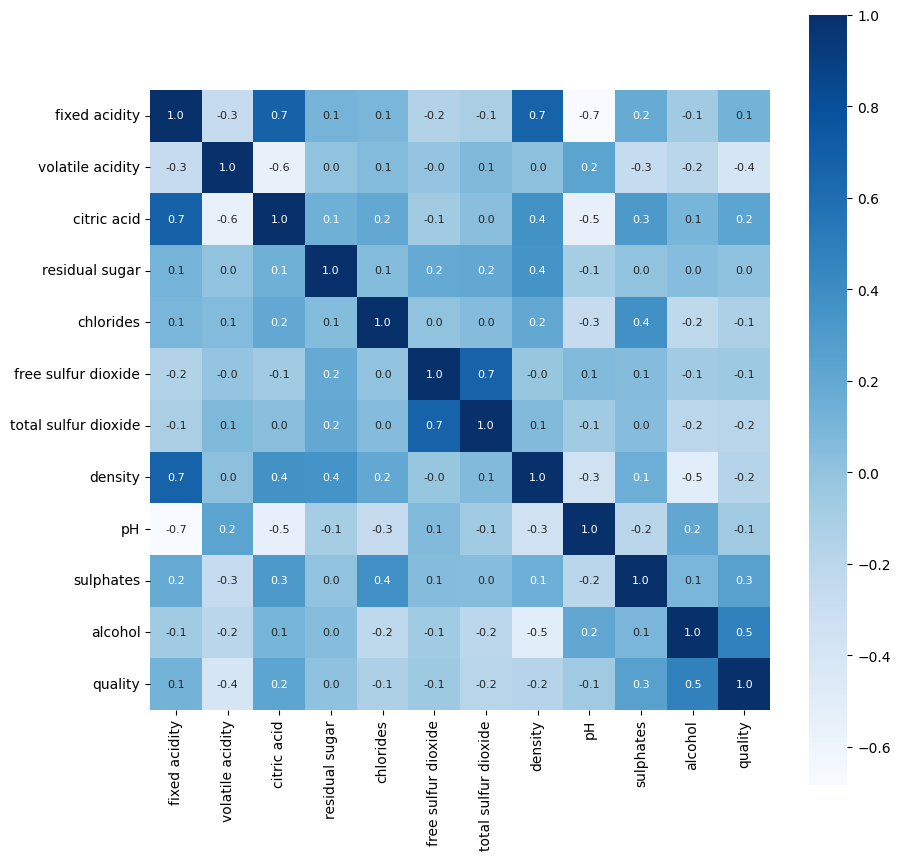

In [ ]:
# Constructing a heatmap to understand relationship between columns
correlation = wine_dataset.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8},cmap='Blues' )

Data Preprocessing

In [ ]:
# Seperate the data and label
X = wine_dataset.drop(['quality'], axis=1)

In [ ]:
print(X)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

Label Binarization

Quality >= 7 --> 1 (Good)

Quality <= 6 --> 0 (Bad)

In [ ]:
Y = wine_dataset['quality'].apply(lambda y_value: 1 if y_value >= 7 else 0)

In [ ]:
print(Y)

0       0
1       0
2       0
3       0
4       0
       ..
1594    0
1595    0
1596    0
1597    0
1598    0
Name: quality, Length: 1599, dtype: int64


Train and Test Split

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(1599, 11) (1279, 11) (320, 11)


Model Training:

Random Forest Classifier

In [ ]:
model = RandomForestClassifier()

In [ ]:
model.fit(X_train, Y_train)

RandomForestClassifier()

Evaluation of Model

In [ ]:
training_data_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(training_data_prediction, Y_train)
print("Accuracy Score on training data is :", training_data_accuracy)

Accuracy Score on training data is : 1.0


In [ ]:
test_data_accuracy = model.predict(X_test)
test_data_accuracy = accuracy_score(test_data_accuracy, Y_test)
print("Accuracy Score on test data is :", test_data_accuracy)

Accuracy Score on test data is : 0.925


Making a Predictive system

In [ ]:
input_data = (7.3, 0.65, 0.0, 1.2, 0.065, 15.0, 21.0, 0.9946, 3.39, 0.47, 10.0)

# changing the input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# Reshaping the data to a 2d array
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Alternate -
# input_data_df = pd.DataFrame([input_data], columns=X_train.columns)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0] == 1):
  print("Good Quality Wine")
else:
  print("Bad Quality Wine")

[1]
Good Quality Wine


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
